# Risk and Performance Measurement Project

## Imports

In [1]:
# multidimensional array utilities
import numpy as np
# more advanced mathematical procedures
import scipy as sp
# tabularized data manipulation
import pandas as pd
# Downloading data from Yahoo finance
import yfinance as yf
# Plotting library
import matplotlib.pyplot as plt
# High level plotting utilities
import seaborn as sns
# Certain functions useful in the project
import utils

## Preparation

Initializing rng generation, plotting theme and some useful global variables

In [2]:
rng = np.random.default_rng()
sns.set_theme()

Getting the symbols currently used in the SP500

In [3]:
# from https://github.com/datasets/s-and-p-500-companies/blob/main/data/constituents.csv
sp500 = pd.read_csv("sp500.csv")
symbols = sp500.loc[:, 'Symbol']
symbols.head()

0     MMM
1     AOS
2     ABT
3    ABBV
4     ACN
Name: Symbol, dtype: object

Selecting symbols starting with letter 'K'

In [4]:
# There weren't enough companies, whose tickers start with 'J',
# so I have used 'K' instead
potential_symbols = symbols.loc[symbols.str[0] == 'K']
potential_symbols

85      KMX
112      KO
267       K
268    KVUE
269     KDP
270     KEY
271    KEYS
272     KMB
273     KIM
274     KMI
275     KKR
276    KLAC
277     KHC
278      KR
Name: Symbol, dtype: object

Randomly choosing the symbols

In [5]:
# The symbols have been randomized and then hard coded for reproducibility
#selected_symbols = rng.choice(potential_symbols, size=10, replace=False)
selected_symbols = ['KDP', 'KKR', 'KIM', 'KLAC', 'KMI', 'KMX', 'KO', 'KEY', 'KR', 'KMB']
selected_symbols = pd.Series(selected_symbols, name='Symbol')
selected_symbols

0     KDP
1     KKR
2     KIM
3    KLAC
4     KMI
5     KMX
6      KO
7     KEY
8      KR
9     KMB
Name: Symbol, dtype: object

Downloading the data

In [6]:
# Download the prices from Yahoo!
tickers = yf.Tickers(" ".join(selected_symbols))
dates_start = "2022-01-01"
dates_end = "2025-01-01"
prices = tickers.history(start=dates_start, end=dates_end, period=None, auto_adjust=False)
prices.to_pickle("prices.pickle")
# or use locally stored data instead
# prices = pd.read_pickle("prices.pickle")
prices.head()

[*********************100%***********************]  10 of 10 completed


Price       Adj Close                                               \
Ticker            KDP        KEY        KIM        KKR        KLAC   
Date                                                                 
2022-01-03  33.169422  19.195248  20.473074  71.031296  417.039490   
2022-01-04  33.666370  20.204666  21.014475  71.794556  413.349243   
2022-01-05  33.628231  20.082561  20.622999  66.644989  403.284821   
2022-01-06  33.991497  21.108263  20.756268  68.200478  414.288605   
2022-01-07  33.873432  21.450159  20.614672  67.147392  399.613770   

Price                                                                ...  \
Ticker             KMB        KMI         KMX         KO         KR  ...   
Date                                                                 ...   
2022-01-03  122.714279  13.034692  127.010002  52.627064  41.449409  ...   
2022-01-04  123.377693  13.218055  123.860001  53.505657  42.348289  ...   
2022-01-05  124.118675  13.289804  119.349998  53.949383  42.935326  ...   
2022-01-06  123.308754  13.568837  119.099998  53.665401  43.219662  ...   
2022-01-07  123.842949  13.768143  121.080002  53.541153  44.136879  ...   

Price        Volume                                                          \
Ticker          KDP       KEY      KIM      KKR     KLAC      KMB       KMI   
Date                                                                          
2022-01-03  3508900   6834300  3482400  2061700  1044300  1994200  14468600   
2022-01-04  5305600   8397900  2962700  5905500   964900  2027100  16821400   
2022-01-05  5777400  10080400  3457800  6245900  1174000  1935600  20913100   
2022-01-06  6505000   9425800  3214700  4383300  1268500  1692700  13691100   
2022-01-07  4939200  11174500  4477100  2937600  1155000  1305300  17813800   

Price                                    
Ticker          KMX        KO        KR  
Date                                     
2022-01-03  1031500  20187300   6024700  
2022-01-04  1568200  26141600  10378100  
2022-01-05  1198900  22507300   8367700  
2022-01-06  1159200  17902300   7115600  
2022-01-07  2329400  12307900   8672700  

[5 rows x 80 columns]

We are only insterested in the adjusted close prices

In [7]:
close_prices = prices.loc[:, "Adj Close"]
close_prices.head()

Ticker,KDP,KEY,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR
Date,,,,,,,,,,
2022-01-03,33.169422,19.195248,20.473074,71.031296,417.039490,122.714279,13.034692,127.010002,52.627064,41.449409
2022-01-04,33.666370,20.204666,21.014475,71.794556,413.349243,123.377693,13.218055,123.860001,53.505657,42.348289
2022-01-05,33.628231,20.082561,20.622999,66.644989,403.284821,124.118675,13.289804,119.349998,53.949383,42.935326
2022-01-06,33.991497,21.108263,20.756268,68.200478,414.288605,123.308754,13.568837,119.099998,53.665401,43.219662
2022-01-07,33.873432,21.450159,20.614672,67.147392,399.613770,123.842949,13.768143,121.080002,53.541153,44.136879


Plotting the prices

In [8]:
# in order to work with seaborn FacetGrid plotting, we need to turn the dataframe
# into a long form dataframe, that is a dataframe where each row represents
# a different observation and each column a separate variable (in our database
# those are 'Ticker' and 'Adj Close')
close_prices_long_form = close_prices.reset_index().melt(id_vars="Date", value_name="Adj Close")
close_prices_long_form.head()

,Date,Ticker,Adj Close
0,2022-01-03,KDP,33.169422
1,2022-01-04,KDP,33.666370
2,2022-01-05,KDP,33.628231
3,2022-01-06,KDP,33.991497
4,2022-01-07,KDP,33.873432


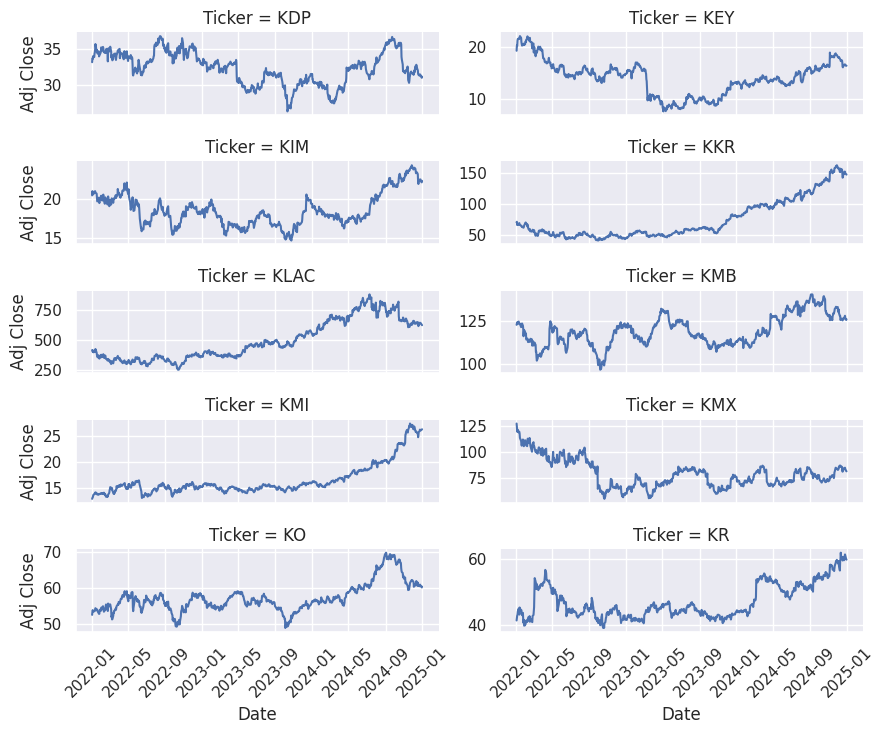

In [9]:
g = sns.FacetGrid(close_prices_long_form, col='Ticker', col_wrap=2, height=1.5, aspect=3, sharey=False)
g.tick_params(axis='x', labelrotation=45)
g.map_dataframe(sns.lineplot, x='Date', y='Adj Close')
plt.savefig("figs/prices.pdf")
plt.show()

## Returns Analysis

### Calculating simple returns

In [10]:
returns = utils.simple_returns(close_prices)
returns.head()

Ticker,KDP,KEY,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR
Date,,,,,,,,,,
2022-01-04,0.014982,0.052587,0.026445,0.010745,-0.008849,0.005406,0.014067,-0.024801,0.016695,0.021686
2022-01-05,-0.001133,-0.006043,-0.018629,-0.071726,-0.024348,0.006006,0.005428,-0.036412,0.008293,0.013862
2022-01-06,0.010802,0.051074,0.006462,0.023340,0.027285,-0.006525,0.020996,-0.002095,-0.005264,0.006622
2022-01-07,-0.003473,0.016197,-0.006822,-0.015441,-0.035422,0.004332,0.014688,0.016625,-0.002315,0.021222
2022-01-10,0.000268,-0.000759,0.015353,-0.002734,0.004366,0.005913,0.009265,-0.019904,0.001658,0.020366


### Characteristics

In [11]:
display(returns.describe())
returns.iloc[:, :5].describe().to_latex("tables/all_returns_characteristics_1.tex")
returns.iloc[:, 5:].describe().to_latex("tables/all_returns_characteristics_2.tex")

Ticker,KDP,KEY,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR
count,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000
mean,-0.000012,0.000163,0.000258,0.001256,0.000897,0.000102,0.001023,-0.000213,0.000233,0.000621
std,0.011886,0.027166,0.016898,0.024038,0.026755,0.011693,0.013570,0.026994,0.009839,0.016241
min,-0.055211,-0.273308,-0.056659,-0.092944,-0.146966,-0.057305,-0.051136,-0.246008,-0.069626,-0.073223
25%,-0.006598,-0.013536,-0.009834,-0.012262,-0.013958,-0.005995,-0.006413,-0.014279,-0.005277,-0.007712
50%,0.000279,-0.000608,0.000503,0.001245,0.000297,0.000564,0.001012,-0.000529,0.000705,0.000443
75%,0.007301,0.012874,0.010394,0.015819,0.017049,0.006500,0.009045,0.013998,0.005646,0.009046
max,0.050673,0.157010,0.075085,0.119873,0.091047,0.081265,0.066370,0.100741,0.038671,0.116062


### Plots

In [12]:
# transform into long form dateframe
returns_long_form = returns.melt(value_vars=selected_symbols, value_name='Return', ignore_index=False)

Line plots

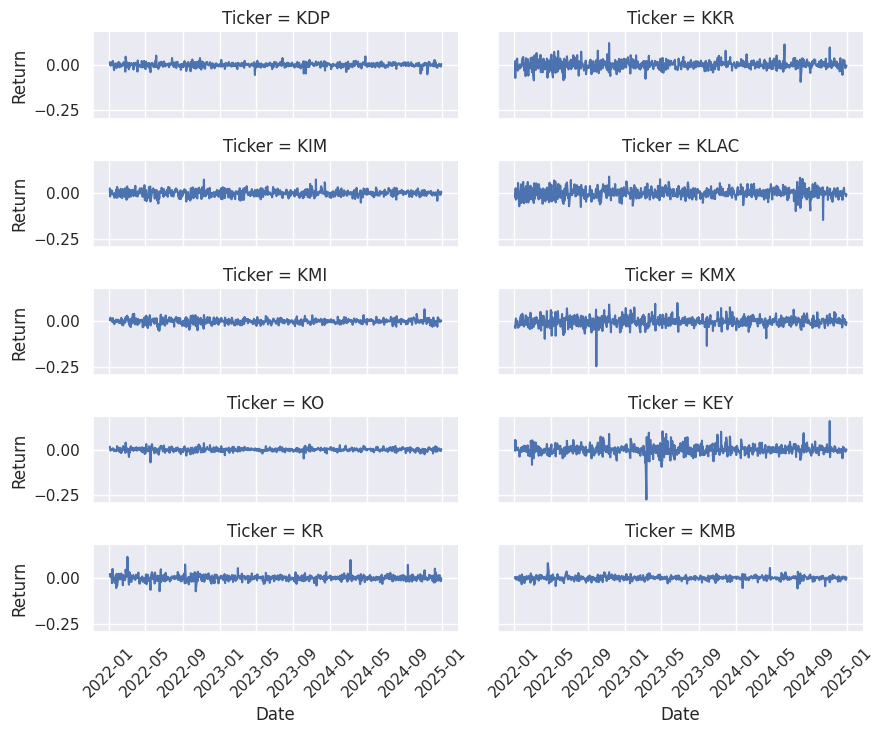

In [13]:
g = sns.FacetGrid(returns_long_form, col='Ticker', col_wrap=2, height=1.5, aspect=3)
g.tick_params(axis='x', labelrotation=45)
g.map_dataframe(sns.lineplot, x='Date', y='Return')
plt.savefig("figs/all_returns.pdf")
plt.show()

Histograms with kernel density estimates

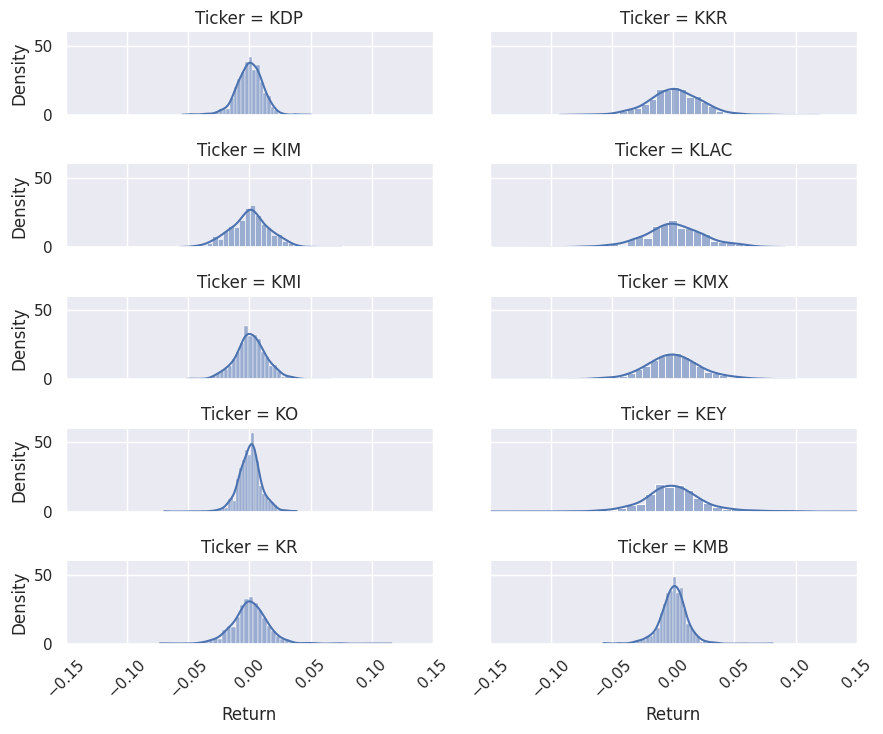

In [14]:
g = sns.FacetGrid(returns_long_form, col='Ticker', col_wrap=2, height=1.5, aspect=3, xlim=[-0.15, 0.15])
g.tick_params(axis='x', labelrotation=45)
g.map_dataframe(sns.histplot, 'Return', kde=True, bins='auto', stat='density')
plt.savefig("figs/all_returns_histograms.pdf")
plt.show()

Boxplots

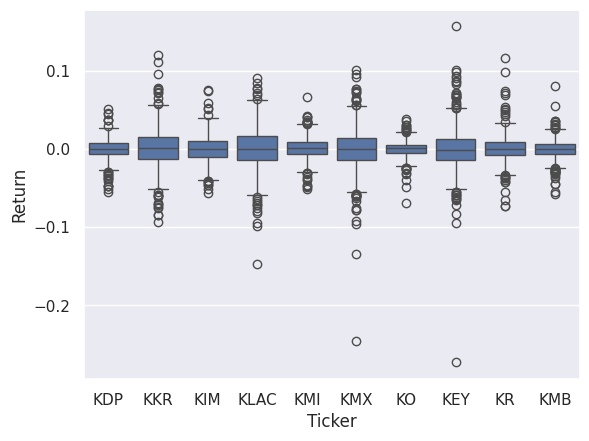

In [15]:
fig, ax = plt.subplots()
sns.boxplot(returns_long_form, x='Ticker', y='Return', ax=ax)
plt.savefig("figs/all_returns_boxplots.pdf")
plt.show()

Covariance matrix

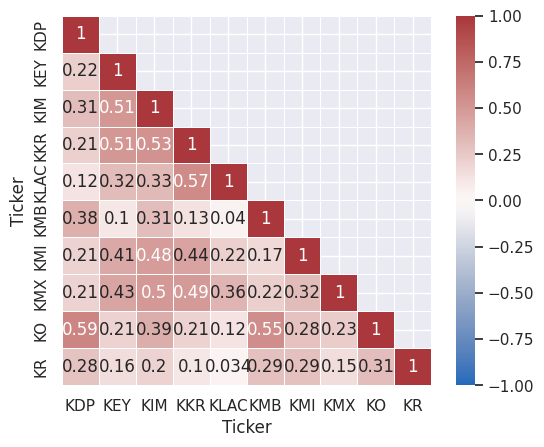

In [16]:
corr = returns.corr()
fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, ax=ax, vmin=-1, vmax=1, square=True, mask=np.triu(np.ones_like(corr), k=1), linewidth=0.5, cmap=sns.color_palette('vlag', as_cmap=True))
plt.savefig("figs/all_returns_correlation.pdf")
plt.show()

## Analysis

Daily returns in the year 2022

In [17]:
returns_2022 = returns.loc["2022-01-01":"2023-01-01"]
returns_2022.head()

Ticker,KDP,KEY,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR
Date,,,,,,,,,,
2022-01-04,0.014982,0.052587,0.026445,0.010745,-0.008849,0.005406,0.014067,-0.024801,0.016695,0.021686
2022-01-05,-0.001133,-0.006043,-0.018629,-0.071726,-0.024348,0.006006,0.005428,-0.036412,0.008293,0.013862
2022-01-06,0.010802,0.051074,0.006462,0.023340,0.027285,-0.006525,0.020996,-0.002095,-0.005264,0.006622
2022-01-07,-0.003473,0.016197,-0.006822,-0.015441,-0.035422,0.004332,0.014688,0.016625,-0.002315,0.021222
2022-01-10,0.000268,-0.000759,0.015353,-0.002734,0.004366,0.005913,0.009265,-0.019904,0.001658,0.020366


Daily P&L with $2000 invested in each stock

In [18]:
pnl_2000_each = 2000*returns_2022
display(utils.describe_pnl(pnl_2000_each))
utils.describe_pnl(pnl_2000_each.iloc[:, :5]).to_latex("tables/pnl_2000_each_1.tex")
utils.describe_pnl(pnl_2000_each.iloc[:, 5:]).to_latex("tables/pnl_2000_each_2.tex")

Ticker,KDP,KEY,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR
mean,0.111550,-1.612251,-0.518326,-2.660522,-0.096134,0.089794,1.592800,-4.767310,0.949274,0.485229
std,26.701919,44.740061,38.679134,60.940088,61.633867,27.666454,34.391096,65.107958,24.846848,42.065761
VaR 1%,73.803530,106.918599,91.817132,158.588360,143.473008,71.431458,95.653801,174.067389,72.100103,137.662615
ES 2.5%,69.979851,107.528479,90.282871,150.180140,132.200645,67.721461,89.683434,209.756450,71.995383,114.439608
SR,0.004178,-0.036036,-0.013401,-0.043658,-0.001560,0.003246,0.046314,-0.073222,0.038205,0.011535
GLR,0.005100,0.000000,0.000000,0.000000,0.000000,0.004353,0.058961,0.000000,0.048219,0.016835


Choosing 3 tickers with the biggest Sharpe Ratio

In [19]:
all_tickers = pnl_2000_each.columns
chosen_tickers = ['KDP', 'KMI', 'KO']
other_tickers = [ticker for ticker in all_tickers if ticker not in chosen_tickers]

Portfolio of chosen tickers with equal allocations

In [20]:
pnl_chosen = pnl_2000_each.loc[:, chosen_tickers].mean(axis=1).rename("Chosen")
pnl_chosen.head()

Date
2022-01-04    30.496087
2022-01-05     8.392237
2022-01-06    17.689708
2022-01-07     5.933244
2022-01-10     7.460313
Name: Chosen, dtype: float64

Portfolio of the other tickers with equal allocations

In [21]:
pnl_other = pnl_2000_each.loc[:, other_tickers].mean(axis=1).rename("Other")
pnl_other.head()

Date
2022-01-04    23.776947
2022-01-05   -39.226096
2022-01-06    30.332583
2022-01-07     0.197640
2022-01-10     6.457435
Name: Other, dtype: float64

Portfolio of all tickers with equal allocations

In [22]:
pnl_all = pnl_2000_each.mean(axis=1).rename("All")
pnl_all.head()

Date
2022-01-04    25.792689
2022-01-05   -24.940596
2022-01-06    26.539721
2022-01-07     1.918321
2022-01-10     6.758298
Name: All, dtype: float64

### Optimizing portfolio

Minimazing mean variance criterion for risk aversion coefficient $\gamma \in [-0.05, 0]$

In [23]:
def pnl_weighed_mean(x):
    return np.sum(x*pnl_2000_each, axis=1)

gamma = np.linspace(-0.05, 0, 200)
weights = np.zeros((len(gamma), len(returns.columns)))
for i, g in enumerate(gamma):
    result = sp.optimize.minimize(
        lambda x: -utils.mean_variance_criterion(pnl_weighed_mean(x), g),
        np.repeat(1/pnl_2000_each.shape[1], pnl_2000_each.shape[1]),
        # [1/len(chosen_tickers) if ticker in chosen_tickers else 0 for ticker in all_tickers],
        bounds=[(0,1)]*pnl_2000_each.shape[1],
        constraints=sp.optimize.LinearConstraint(np.repeat(1, pnl_2000_each.shape[1]), 1, 1))
    weights[i] = result.x
    print(f"{i+1}/{len(gamma)}", end='\r')

200/200

Risk measures and performace criterions for the found portfolios

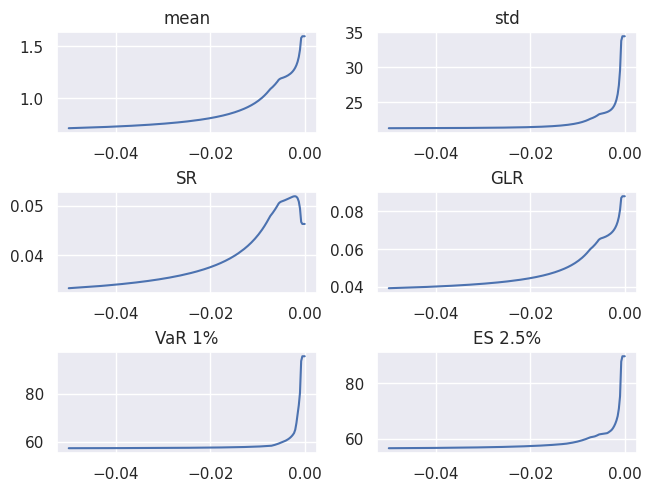

In [24]:
pnl_frontier = np.sum(np.expand_dims(weights, axis=1)*pnl_2000_each.values, axis=-1)
means = np.mean(pnl_frontier, axis=-1)
stds = np.std(pnl_frontier, axis=-1, ddof=1)
sharpe_ratios = utils.sharpe_ratio(pnl_frontier, axis=-1)
gain_loss_ratios = utils.gain_loss_ratio(pnl_frontier, axis=-1)
vars_ = utils.value_at_risk(pnl_frontier, 0.01, axis=-1)
ess = utils.expected_shortfall(pnl_frontier, 0.025, axis=-1)
fig, axs = plt.subplots(3, 2, layout='constrained')
axs[0, 0].plot(gamma, means)
axs[0, 1].plot(gamma, stds)
axs[1, 0].plot(gamma, sharpe_ratios)
axs[1, 1].plot(gamma, gain_loss_ratios)
axs[2, 0].plot(gamma, vars_)
axs[2, 1].plot(gamma, ess)
axs[0, 0].set_title("mean")
axs[0, 1].set_title("std")
axs[1, 0].set_title("SR")
axs[1, 1].set_title("GLR")
axs[2, 0].set_title("VaR 1%")
axs[2, 1].set_title("ES 2.5%")
fig.savefig("figs/frontier_stats.pdf")
plt.show()

Weights for the symbols in portfolio for different $\gamma$

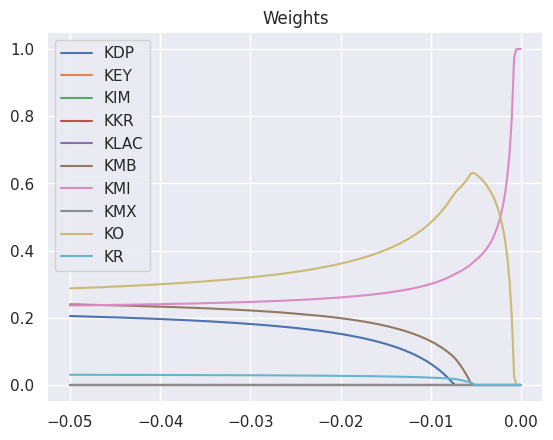

In [25]:
plt.plot(np.repeat(np.linspace(-0.05, 0, 200)[:, np.newaxis], 10, axis=1), weights, label=returns.columns)
plt.legend()
plt.title("Weights")
plt.savefig("figs/frontier_weights.pdf")
plt.show()

We choose the risk aversion coefficient, for which Sharpe's Ratio is the greatest

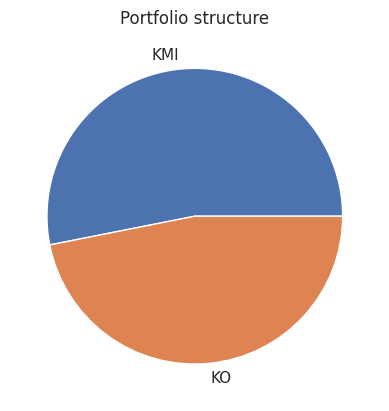

Risk aversion coefficient: -0.002010050251256279


In [26]:
argmax = np.argmax(sharpe_ratios)
w = weights[argmax]
w[w < 1e-10] = 0
w = w / np.sum(w)
optimal_tickers = [ticker for i, ticker in enumerate(returns.columns) if w[i] != 0]
w_clean = [w_ for w_ in w if w_ != 0]
plt.pie(w_clean, labels=optimal_tickers)
plt.title("Portfolio structure")
plt.savefig("figs/portfolio_structure.pdf")
plt.show()
print(f"Risk aversion coefficient: {gamma[argmax]}")

Returns of the optimized portfolio

In [27]:
pnl_optimized = pd.Series(pnl_weighed_mean(w), name="Optimized")
pnl_optimized.head()

Date
2022-01-04    30.598372
2022-01-05    13.542787
2022-01-06    17.367653
2022-01-07    13.432248
2022-01-10    11.395996
Name: Optimized, dtype: float64

In [28]:
pnl_chosen_description = utils.describe_pnl(pnl_chosen)
pnl_other_description = utils.describe_pnl(pnl_other)
pnl_all_description = utils.describe_pnl(pnl_all)
pnl_optimized_description = utils.describe_pnl(pnl_optimized)
descriptions = pd.concat([pnl_chosen_description, pnl_other_description, pnl_all_description, pnl_optimized_description], axis=1)
display(descriptions)
descriptions.to_latex("tables/statistics_averages.tex")

,Chosen,Other,All,Optimized
mean,0.884541,-1.297074,-0.642590,1.291077
std,22.426511,35.170553,29.687334,24.861040
VaR 1%,58.017764,97.583536,79.200162,64.934237
ES 2.5%,56.840570,90.297815,77.390139,65.398112
SR,0.039442,-0.036880,-0.021645,0.051932
GLR,0.048367,0.000000,0.000000,0.065753


## Backtesting

### Preparing data

In [29]:
start = "2023-01-01"
end = "2024-01-01"
lookback = 250

returns_all = returns.mean(axis=1).rename("All")
returns_optimized = np.sum(result.x*returns, axis=1).rename("Optimized")
returns_df = pd.concat([returns_all, returns_optimized], axis=1)
returns_df.head()

,All,Optimized
Date,,
2022-01-04,0.012896,0.014067
2022-01-05,-0.012470,0.005428
2022-01-06,0.013270,0.020996
2022-01-07,0.000959,0.014688
2022-01-10,0.003379,0.009265


### VaR

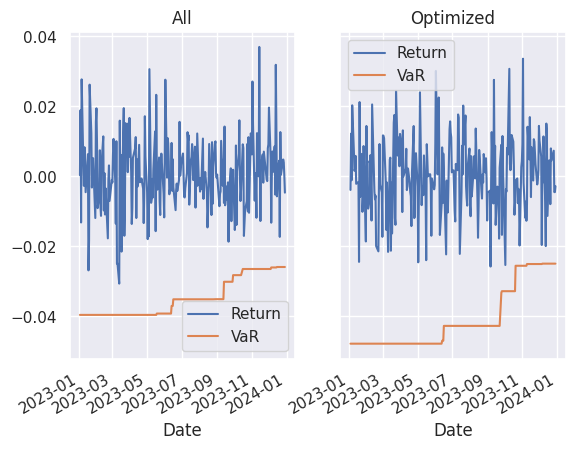

Violations:
All          0
Optimized    0
dtype: int64


In [30]:
realized, var = utils.var_backtest(returns_df, lookback=lookback, start=start, end=end, alpha=0.01)
fig, axs = plt.subplots(1, 2, sharey=True)
for i, column in enumerate(returns_df.columns):
    realized.loc[:, column].plot(ax=axs[i])
    (-var).loc[:, column].plot(ax=axs[i])
    axs[i].set_title(column)
    axs[i].legend(['Return', 'VaR'])
fig.savefig("figs/var_backtest.pdf")
plt.show()
print("Violations:")
print((realized < -var).sum())

### PIT

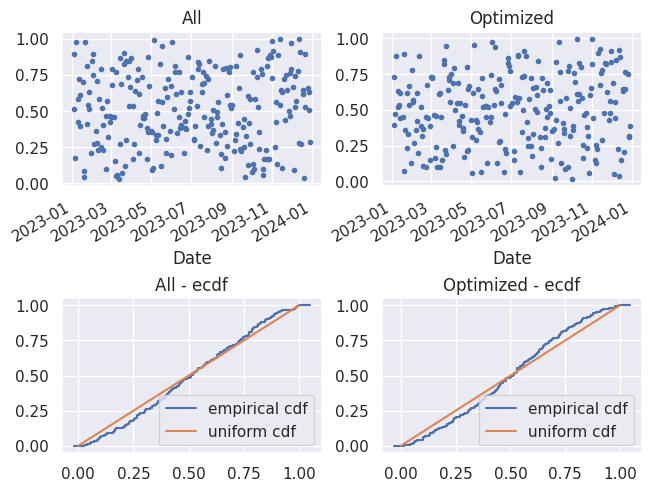

Kolmogorov-Smirnov goodness of fit test:
    All:
        statistic=0.07600000000000001
        p value=0.10572937852947173
    Optimized:
        statistic=0.07600000000000007
        p value=0.10572937852947129


In [31]:
realized, pit = utils.pit_backtest(returns_df, lookback=lookback, start=start, end=end)
fig, axs = plt.subplots(2, 2, layout='constrained')
for i, column in enumerate(returns_df.columns):
    pit.loc[:, column].plot(style='.', ax=axs[0, i])
    sp.stats.ecdf(pit.loc[:, column]).cdf.plot(ax=axs[1, i], label='empirical cdf')
    axs[1, i].plot([0, 1], [0, 1], label='uniform cdf')
    axs[0, i].set_title(column)
    axs[1, i].set_title(f"{column} - ecdf")
    axs[1, i].legend()
fig.savefig("figs/pit_backtest.pdf")
plt.show()
print("Kolmogorov-Smirnov goodness of fit test:")
for i, column in enumerate(returns_df.columns):
    res = sp.stats.kstest(pit.loc[:, column], 'uniform')
    print(f"    {column}:")
    print(f"        statistic={res.statistic}")
    print(f"        p value={res.pvalue}")

## Results in 2024

Statistics for the realized returns in 2024

In [32]:
pnl_2024 = 2000*returns_df.loc["2024-01-01":"2025-01-01"]
display(utils.describe_pnl(pnl_2024))
utils.describe_pnl(pnl_2024).to_latex("tables/pnl_2024.tex")

,All,Optimized
mean,1.950528,4.087039
std,16.695498,23.444084
VaR 1%,46.097748,58.314095
ES 2.5%,41.987419,52.764829
SR,0.116830,0.174331
GLR,0.163592,0.282769


Correlation between portfolios

In [33]:
pnl_2024.corr()

,All,Optimized
All,1.000000,0.571869
Optimized,0.571869,1.000000
